# Time Rabi: load saved arrays → plot → fit



This notebook is analysis-only:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)

- Plot the raw arrays and normalized signal

- Fit the oscillation


## 1) Imports + locate NV2_array


In [21]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "qua-libs").exists():
            return p

WORKSPACE = find_workspace_root(Path.cwd())

ANALYSIS = (WORKSPACE / "qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array/analysis").resolve()

NV2 = ANALYSIS.parent

DATA_ROOT = NV2 / "Data"

sys.path.insert(0, str(ANALYSIS))

from nv2_analysis.dataset import DatasetReader  # noqa: E402
from nv2_analysis.fits import ExperimentFitter  # noqa: E402

plt.rcParams["figure.figsize"] = (9, 5)

CC_NS = 4.0

## 2) Load saved arrays


In [22]:
reader = DatasetReader(nv_root=NV2, data_root=DATA_ROOT)

EXPERIMENT_TAG = "time_rabi"  # matches dataset folder names like '#17_time_rabi_155155'

# Choose a specific dataset folder or leave None for "latest":

#   DATASET = None

#   DATASET = r"2025-12-31\#17_time_rabi_155155"  # relative to Data/

#   DATASET = r"C:\\...\\NV2_array\\Data\\2025-12-31\\#17_time_rabi_155155"  # absolute

DATASET = None

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob("data.json") if p.is_file() and tag in p.parent.name]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")

    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)

data = reader.load(ds)

t_vec = np.asarray(data["t_vec"], dtype=float)  # clock cycles
counts_data = np.asarray(data["counts_data"], dtype=float)
counts_ref_data = np.asarray(data["counts_ref_data"], dtype=float)

cfg = data.get("config") or {}
pulses = cfg.get("pulses") or {}
readout_len_ns = float(pulses["readout_pulse_1"]["length"])  # meas_len_1
meas_len_s = readout_len_ns * 1e-9

t_ns = t_vec * CC_NS

signal_kcps = counts_data / 1000.0 / meas_len_s
ref_kcps = counts_ref_data / 1000.0 / meas_len_s


normalized_data = -(ref_kcps - signal_kcps) / ref_kcps

print(f"Loaded: {ds.folder}")


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array\Data\2026-01-01\#26_time_rabi_175719


## 3) Plot original arrays


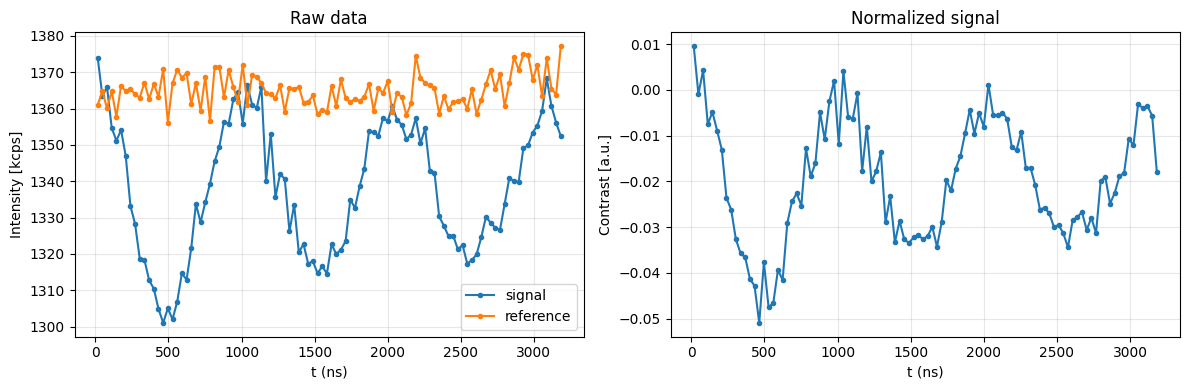

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t_ns, signal_kcps, "o-", ms=3, label="signal")
ax[0].plot(t_ns, ref_kcps, "o-", ms=3, label="reference")
ax[0].set_xlabel("t (ns)")
ax[0].set_ylabel("Intensity [kcps]")
ax[0].set_title("Raw data")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(t_ns, normalized_data, "o-", ms=3)
ax[1].set_xlabel("t (ns)")
ax[1].set_ylabel("Contrast [a.u.]")
ax[1].set_title("Normalized signal")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4) Fit


In [24]:
from importlib import reload
import nv2_analysis.fits as fits
reload(fits)
fitter = fits.ExperimentFitter()
fit_res = fitter.fit_time_rabi({"t_vec": t_vec, "counts_data": counts_data, "counts_ref_data": counts_ref_data, "normalized_data": normalized_data})

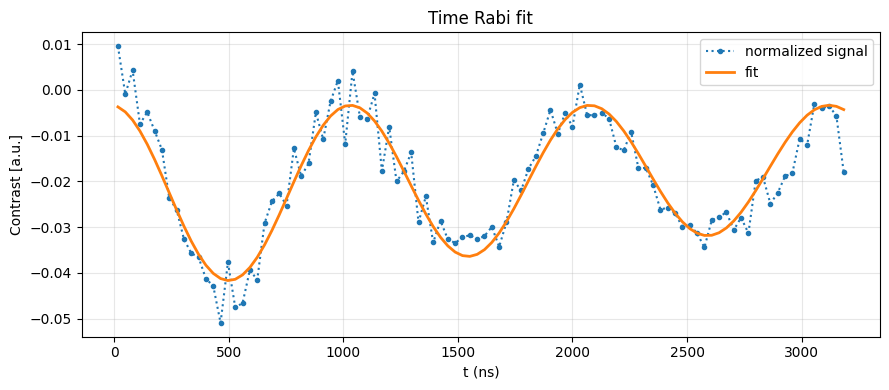

Fit function:
y(t) = amp * cos(2π f t + phase) * exp(-t/T) + offset
  amp=-0.04115338870915765, f=0.0009568101895031604 1/ns, phase=0.04532904256481313 rad, offset=-0.0033484517889460254, T=7063.332724251567 ns

Derived times:
- period: 1045.139 ns
- t_pi (half-period): 522.570 ns
- t_pi (phase-adjusted, first cos minimum): 515.030 ns


In [26]:
# Plot first
if "fit_res" not in globals() or fit_res is None:
    from importlib import reload
    import nv2_analysis.fits as fits
    reload(fits)
    fitter = fits.ExperimentFitter()
    fit_res = fitter.fit_time_rabi({"t_vec": t_vec, "counts_data": counts_data, "counts_ref_data": counts_ref_data, "normalized_data": normalized_data})

x = getattr(fit_res, "x", None)
y = getattr(fit_res, "y", None)
y_fit = getattr(fit_res, "y_fit", None)
if x is None:
    x = t_ns
if y is None:
    y = normalized_data

plt.figure(figsize=(9, 4))
plt.plot(x, y, marker="o", linestyle=":", ms=3, label="normalized signal")
if y_fit is not None:
    plt.plot(x, y_fit, "-", lw=2, label="fit")
plt.xlabel("t (ns)")
plt.ylabel("Contrast [a.u.]")
plt.title("Time Rabi fit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Then print fit details
def as_scalar(v):
    try:
        a = np.asarray(v, dtype=float).ravel()
        return float(a[0]) if a.size else None
    except Exception:
        return None

amp = as_scalar(fit_res.params.get("amp"))
f = as_scalar(fit_res.params.get("f"))
phase = as_scalar(fit_res.params.get("phase"))
offset = as_scalar(fit_res.params.get("offset"))
T = as_scalar(fit_res.params.get("T"))

print("Fit function:")
if all(v is not None for v in [amp, f, phase, offset]):
    if T is not None and T > 0:
        print("y(t) = amp * cos(2π f t + phase) * exp(-t/T) + offset")
    else:
        print("y(t) = amp * cos(2π f t + phase) + offset")
    print(f"  amp={amp}, f={f} 1/ns, phase={phase} rad, offset={offset}, T={T} ns")
else:
    print("Could not format analytic function (missing amp/f/phase/offset).")

print("\nDerived times:")
if f is not None and f > 0:
    period_ns = 1.0 / f
    t_pi_halfperiod_ns = 0.5 / f
    print(f"- period: {period_ns:.3f} ns")
    print(f"- t_pi (half-period): {t_pi_halfperiod_ns:.3f} ns")
    if phase is not None:
        t_pi_phase_ns = ((np.pi - phase) % (2.0 * np.pi)) / (2.0 * np.pi * f)
        print(f"- t_pi (phase-adjusted, first cos minimum): {t_pi_phase_ns:.3f} ns")
else:
    print("Could not compute t_pi (missing/invalid f).")